In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [9]:
x, _ = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

In [10]:
print("Shape:", x.shape)
print(x[:5])

Shape: (300, 2)
[[-7.43086027 -7.89992284]
 [-7.91212323 -7.34157625]
 [-1.52214373  7.54927375]
 [ 4.37866139  3.29170191]
 [-9.32537663 -8.08981317]]


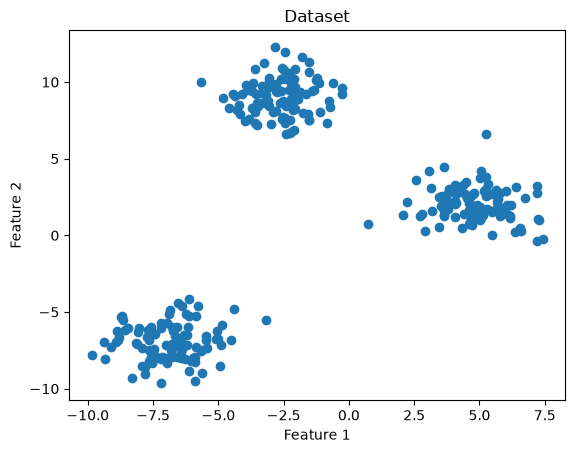

In [11]:
plt.scatter(x[:, 0], x[:, 1])

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset")

plt.show()

In [12]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [14]:
kmeans.fit(x_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[[-0.

In [15]:
labels = kmeans.labels_

print(labels[:20])

[1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0]


In [16]:
print(kmeans.cluster_centers_)

[[-0.21518875  1.15316649]
 [-1.06790185 -1.25264527]
 [ 1.2830906   0.09947878]]


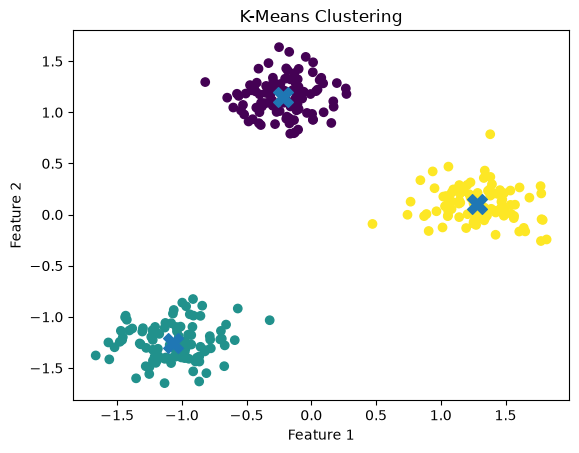

In [17]:
plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1],
    c=labels
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.show()

In [ ]:
# Cluster Labels

In [18]:
df = pd.DataFrame(x, columns=["feature_1", "feature_2"])

df["cluster"] = labels

df.head()

,feature_1,feature_2,cluster
0,-7.430860,-7.899923,1
1,-7.912123,-7.341576,1
2,-1.522144,7.549274,0
3,4.378661,3.291702,2
4,-9.325377,-8.089813,1


In [19]:
print(df["cluster"].value_counts().sort_index())

cluster
0    100
1    100
2    100
Name: count, dtype: int64


In [20]:
print(df.groupby("cluster")[["feature_1", "feature_2"]].mean())

         feature_1  feature_2
cluster                      
0        -2.658040   9.049427
1        -6.884721  -7.004759
2         4.768548   2.018079


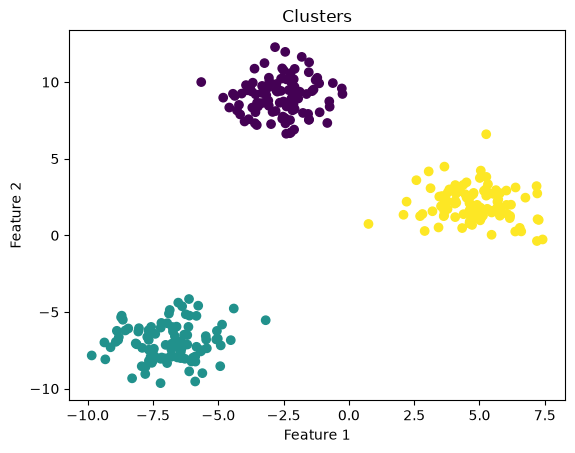

In [21]:
plt.scatter(
    df["feature_1"],
    df["feature_2"],
    c=df["cluster"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Clusters")

plt.show()

In [22]:
new_point = [[0.5, -0.2]]

new_point_scaled = scaler.transform(new_point)

cluster = kmeans.predict(new_point_scaled)

print(cluster)

[2]


In [23]:
# Elbow Method to calculate the perfect k value

In [24]:
inertia_values = []

In [25]:
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(x_scaled)
    
    inertia_values.append(kmeans.inertia_)

In [27]:
for k, inertia in zip(range(1, 11), inertia_values):
    print(f"K={k:<2} | Inertia={inertia:.2f}")

K=1  | Inertia=600.00
K=2  | Inertia=193.57
K=3  | Inertia=25.81
K=4  | Inertia=21.86
K=5  | Inertia=18.00
K=6  | Inertia=15.13
K=7  | Inertia=13.46
K=8  | Inertia=11.88
K=9  | Inertia=10.50
K=10 | Inertia=9.56


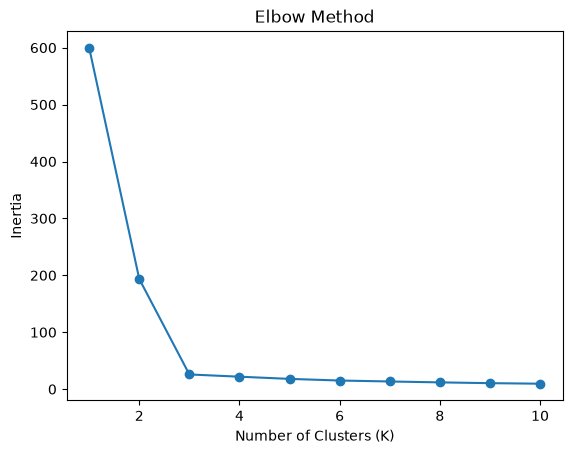

In [28]:
plt.plot(range(1, 11), inertia_values, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
# silhouette_score

In [29]:
from sklearn.metrics import silhouette_score

In [30]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(x_scaled)

score = silhouette_score(x_scaled, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.8182412709664815


In [32]:
silhouette_values = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(x_scaled)
    
    score = silhouette_score(x_scaled, labels)
    
    silhouette_values.append(score)
    
    print(f"K={k:<2} | Silhouette Score={score:.4f}")

K=2  | Silhouette Score=0.6712
K=3  | Silhouette Score=0.8182
K=4  | Silhouette Score=0.6576
K=5  | Silhouette Score=0.5077
K=6  | Silhouette Score=0.3593
K=7  | Silhouette Score=0.3680
K=8  | Silhouette Score=0.3666
K=9  | Silhouette Score=0.3533
K=10 | Silhouette Score=0.3629


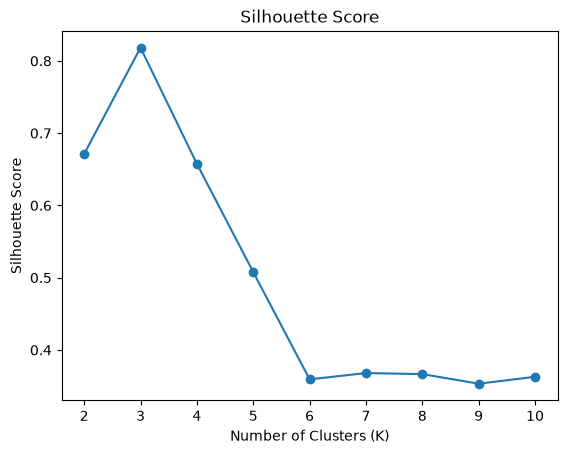

In [33]:
plt.plot(
    range(2, 11),
    silhouette_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

In [34]:
# Choosing the Final K & Training the Final K-Means Model

In [35]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [36]:
final_labels = final_kmeans.fit_predict(x_scaled)

In [37]:
print("Cluster Centers:")
print(final_kmeans.cluster_centers_)

Cluster Centers:
[[-0.21518875  1.15316649]
 [-1.06790185 -1.25264527]
 [ 1.2830906   0.09947878]]


In [38]:
print("Final Inertia:", final_kmeans.inertia_)

Final Inertia: 25.814882630651763


In [39]:
final_silhouette = silhouette_score(
    x_scaled,
    final_labels
)

print("Final Silhouette Score:", final_silhouette)

Final Silhouette Score: 0.8182412709664815


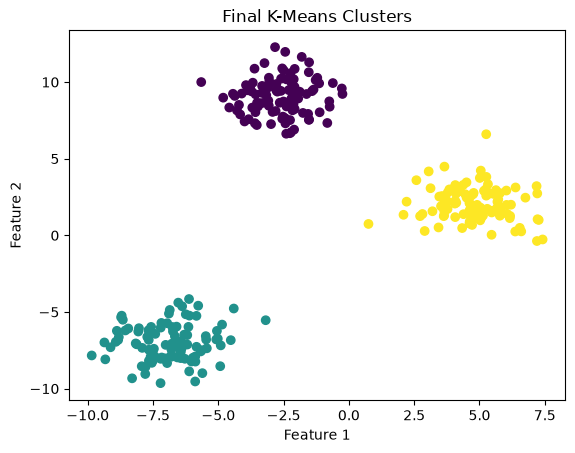

In [40]:
plt.scatter(
    x[:, 0],
    x[:, 1],
    c=final_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final K-Means Clusters")

plt.show()

In [41]:
centers_original = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

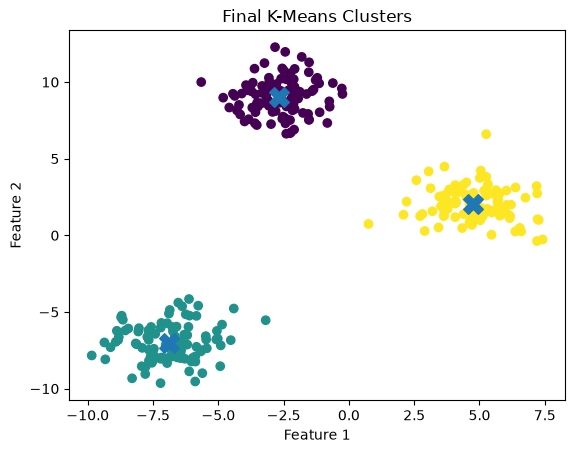

In [42]:
plt.scatter(
    x[:, 0],
    x[:, 1],
    c=final_labels
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final K-Means Clusters")

plt.show()

# K-Means Clustering — Notes

## 1. Unsupervised Learning

**Unsupervised Learning** is a type of machine learning where the dataset does **not have a target variable (`y`)**.

The model tries to discover hidden patterns or structures in the data.

### Main types

* **Clustering** → group similar observations
* **Dimensionality Reduction** → reduce number of features while preserving useful information

---

# 2. Clustering

**Clustering** is the process of grouping similar data points together.

The goal is:

> Points within the same cluster should be similar, while points in different clusters should be different.

Example:

```text
Customer Data
     ↓
Clustering
     ↓
┌──────────────┐
│ Cluster 0    │ → Low spending customers
│ Cluster 1    │ → Medium spending customers
│ Cluster 2    │ → High spending customers
└──────────────┘
```

There is no predefined target label.

---

# 3. K-Means Clustering

**K-Means** is a centroid-based unsupervised clustering algorithm.

It divides the data into **K clusters**.

The algorithm tries to make points within each cluster as close as possible to their cluster's centroid.

### Important idea

```text
Data points
     ↓
Choose K
     ↓
Initialize centroids
     ↓
Assign points to nearest centroid
     ↓
Calculate new centroids
     ↓
Repeat
     ↓
Final clusters
```

---

# 4. What is K?

`K` represents the **number of clusters** we want.

Example:

```python
KMeans(n_clusters=3)
```

means:

> Create 3 clusters.

K-Means requires us to specify K beforehand.

---

# 5. Centroid

A **centroid** is the center/mean position of a cluster.

For a 2-dimensional cluster:

```text
      ● ●
    ● ● ●
     ✕
    ● ●
```

`✕` represents the centroid.

The centroid is calculated using the **mean of the points belonging to that cluster**.

---

# 6. K-Means Algorithm

## Step 1 — Choose K

Example:

```text
K = 3
```

---

## Step 2 — Initialize centroids

K-Means initially places 3 centroids.

```text
       ✕
       
  ✕
       
             ✕
```

---

## Step 3 — Assign points

Each point is assigned to the **nearest centroid**.

```text
Point
  ↓
Calculate distance to centroids
  ↓
Choose nearest centroid
  ↓
Assign to that cluster
```

---

## Step 4 — Recalculate centroids

After assigning points, calculate a new centroid for each cluster.

```text
Old centroid
     ↓
Mean of cluster points
     ↓
New centroid
```

---

## Step 5 — Repeat

K-Means repeatedly performs:

```text
Assign points
     ↓
Update centroids
     ↓
Assign points
     ↓
Update centroids
     ↓
...
```

until the centroids/clusters stop changing significantly.

---

# 7. Distance

K-Means commonly uses **Euclidean distance**.

For two points:

$$
d = \sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}
$$

Conceptually:

```text
Distance between point and centroid
              ↓
      Smaller distance
              ↓
      More likely same cluster
```

---

# 8. Feature Scaling

Feature scaling is generally important for K-Means because K-Means relies on **distance**.

Example:

```text
Age       → 20–60
Salary    → 20,000–200,000
```

Without scaling, the larger numerical range of salary can dominate distance calculations.

Common approach:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)
```

Then train K-Means using:

```python
kmeans.fit(x_scaled)
```

### Important

```text
x
↓
StandardScaler
↓
x_scaled
↓
K-Means
```

---

# 9. K-Means Implementation

```python
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(x_scaled)
```

### Parameters

### `n_clusters`

```python
n_clusters=3
```

Number of clusters.

---

### `random_state`

```python
random_state=42
```

Makes results reproducible.

---

### `n_init`

```python
n_init=10
```

K-Means can start with different initial centroid positions.

`n_init=10` means it tries multiple initializations and keeps the best result based on inertia.

---

# 10. `fit()`

```python
kmeans.fit(x_scaled)
```

Trains the K-Means algorithm and learns the clusters.

---

# 11. `predict()`

```python
kmeans.predict(x_new_scaled)
```

Assigns new observations to the nearest learned cluster centroid.

---

# 12. `fit_predict()`

```python
labels = kmeans.fit_predict(x_scaled)
```

Performs:

```text
fit
+
predict
```

in one operation.

It returns the cluster labels directly.

Example:

```text
[1, 1, 0, 2, 1, 0, 2, ...]
```

---

# 13. Cluster Labels

The model assigns each observation a cluster number.

Example:

```text
Observation    Cluster
-----------    -------
0              1
1              1
2              0
3              2
4              1
```

### Important

Cluster numbers are **arbitrary**.

For example:

```text
Cluster 0
```

doesn't inherently mean "low-value customers."

It could just as easily be:

```text
Cluster 2 → low-value customers
```

You interpret clusters by examining their features.

---

# 14. `labels_`

After fitting:

```python
kmeans.labels_
```

returns the cluster assigned to each observation.

---

# 15. Cluster Centers

```python
kmeans.cluster_centers_
```

returns the coordinates of the centroids.

If K = 3 and there are 2 features:

```text
3 centroids
×
2 coordinates
```

The centers are in the **scaled feature space** if K-Means was trained on `x_scaled`.

---

# 16. Inertia

**Inertia** measures how close observations are to their assigned centroids.

Conceptually:

```text
Each point
    ↓
Distance to its centroid
    ↓
Square distance
    ↓
Sum all squared distances
    ↓
Inertia
```

K-Means tries to minimize inertia.

### Lower inertia

Generally means:

> Points are closer to their centroids.

---

# 17. Why Not Simply Choose the Lowest Inertia?

Because inertia generally decreases when K increases.

Example:

```text
K = 1  → 600
K = 2  → 193
K = 3  → 25
K = 4  → 21
K = 5  → 18
...
K = 10 → 9
```

So `K=10` has lower inertia than `K=3`.

But that doesn't mean 10 clusters are better.

If we keep increasing K, we can keep reducing inertia.

Therefore, we need another method to select K.

---

# 18. Elbow Method

The **Elbow Method** helps determine a suitable value of K.

We calculate inertia for several K values:

```text
K = 1
K = 2
K = 3
...
K = 10
```

Then plot:

```text
K vs Inertia
```

Example:

```text
Inertia
  ↑
  │●
  │ \
  │  \
  │   ●
  │    \
  │     ●
  │      ●────●────●
  └──────────────────→ K
       1  2  3  4
```

The point where the curve starts becoming much flatter is the **elbow**.

### Your result

```text
K=1 → 600.00
K=2 → 193.57
K=3 → 25.81
K=4 → 21.86
K=5 → 18.00
...
```

There is a very large improvement until `K=3`, after which improvements become much smaller.

Therefore:

> **Elbow Method → K = 3**

---

# 19. Silhouette Score

The **Silhouette Score** evaluates how well each observation fits its assigned cluster.

It considers:

* similarity to its own cluster
* separation from other clusters

Conceptually:

```text
Good cluster

Close to own cluster
        +
Far from other clusters
        ↓
High Silhouette Score
```

---

# 20. Silhouette Score Range

Silhouette Score ranges from:

$$
-1 \text{ to } +1
$$

|       Score | Meaning                     |
| ----------: | --------------------------- |
| Close to +1 | Very good separation        |
|    Around 0 | Overlapping / boundary      |
|    Negative | Potentially poor assignment |

For Silhouette Score:

> **Higher is generally better.**

---

# 21. Your Silhouette Results

```text
K=2  → 0.6712
K=3  → 0.8182 ⭐
K=4  → 0.6576
K=5  → 0.5077
K=6  → 0.3593
K=7  → 0.3680
K=8  → 0.3666
K=9  → 0.3533
K=10 → 0.3629
```

The highest score is:

```text
K = 3
Silhouette = 0.8182
```

Therefore:

> **Silhouette Score → K = 3**

This agrees with the Elbow Method.

---

# 22. Elbow vs Silhouette

| Method           | Measures                 | Better direction |
| ---------------- | ------------------------ | ---------------- |
| Elbow Method     | Inertia / compactness    | Lower inertia    |
| Silhouette Score | Compactness + separation | Higher score     |

For your dataset:

```text
Elbow
  ↓
K = 3

Silhouette
  ↓
K = 3

Visual inspection
  ↓
3 clearly separated groups

      ↓

Final K = 3
```

---

# 23. Final K-Means Model

Once K is selected, train the final model:

```python
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(x_scaled)
```

Then evaluate:

```python
print(final_kmeans.inertia_)

final_silhouette = silhouette_score(
    x_scaled,
    final_labels
)

print(final_silhouette)
```

---

# 24. `inverse_transform()`

K-Means was trained on:

```python
x_scaled
```

Therefore:

```python
final_kmeans.cluster_centers_
```

contains centroids in the **scaled coordinate system**.

To convert them back to the original feature scale:

```python
centers_original = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)
```

### Important

`inverse_transform()` does **not**:

* retrain K-Means
* change cluster assignments
* change labels
* change Silhouette Score
* change the clustering

It only converts:

```text
scaled coordinates
       ↓
inverse_transform()
       ↓
original coordinates
```

---

# 25. Why the Plot Looks the Same After `inverse_transform()`

The data points are still:

```python
x[:, 0]
x[:, 1]
```

The clusters are still:

```python
final_labels
```

Only the centroid coordinates are converted back to the original scale.

Therefore:

```text
Same data
+
Same labels
+
Same clusters
+
Centroids displayed in original scale
```

So the clustering visualization remains the same.

---

# 26. K-Means Limitations

K-Means works best when clusters are relatively:

* compact
* spherical
* well separated

It can struggle with:

### Irregular shapes

```text
Curved / complex clusters
```

### Outliers

Because centroids are based on means.

### Different densities

K-Means doesn't explicitly model density.

### Different cluster shapes

One centroid may not represent a complicated cluster well.

### Choosing K

K must be selected beforehand, although methods such as Elbow and Silhouette help.

### Feature scaling

Distance-based clustering can be strongly affected by feature scales.

---

# 27. When K-Means Is a Good Choice

Use K-Means when:

* Data is primarily numerical
* Distance is meaningful
* Clusters are relatively compact
* Clusters are reasonably separated
* A reasonable K can be determined
* You want a simple and efficient clustering algorithm

Example:

```text
Customer data
      ↓
K-Means
      ↓
Customer segments
```

---

# 28. When K-Means May Not Be Appropriate

Be cautious when:

* Clusters have irregular shapes
* There are many severe outliers
* Cluster densities differ greatly
* K is difficult to determine
* Distance isn't meaningful for the features
* The true structure is density-based

In these situations, other algorithms may be better.

---

# 29. K-Means vs Other Clustering Algorithms

| Algorithm                   | Main Idea                      |
| --------------------------- | ------------------------------ |
| **K-Means**                 | Centroid-based                 |
| **Hierarchical Clustering** | Builds hierarchy of clusters   |
| **DBSCAN**                  | Density-based                  |
| **GMM**                     | Probability/distribution-based |

Mental model:

```text
K-Means
   ↓
Centroids

Hierarchical
   ↓
Hierarchy / Dendrogram

DBSCAN
   ↓
Density

GMM
   ↓
Probability
```

---

# 30. Complete K-Means Workflow

```text
Dataset
   ↓
Select features
   ↓
Feature scaling
   ↓
Try different K values
   ↓
Calculate inertia
   ↓
Elbow Method
   ↓
Calculate Silhouette Score
   ↓
Choose K
   ↓
Train final K-Means
   ↓
Get cluster labels
   ↓
Analyze clusters
   ↓
Visualize clusters
   ↓
Interpret clusters
```

---

# ⭐ Key Things to Remember

### K-Means

> Centroid-based clustering algorithm that divides observations into K clusters.

### K

> Number of clusters.

### Centroid

> Mean/center of a cluster.

### Inertia

> Sum of squared distances of observations from their assigned centroids.

### Elbow Method

> Uses the inertia curve to find a reasonable K.

### Silhouette Score

> Measures how well observations fit within their own clusters and how separated they are from other clusters.

### `fit_predict()`

> Fits K-Means and returns cluster labels.

### `cluster_centers_`

> Returns the learned centroids.

### `labels_`

> Returns cluster assignments.

### `inverse_transform()`

> Converts scaled values back to their original feature scale.

### Your dataset

```text
Elbow       → K = 3
Silhouette  → K = 3
Visual      → 3 clear clusters

Final K = 3 🎯
```